<div dir="rtl" style="text-align: right;">

# تحلیل داده‌های دسته‌بندی شده (Categorical Data): آموزش جامع برای تدریس

این فایل آموزشی به موضوع **تحلیل داده‌های دسته‌بندی شده** اختصاص دارد و برای تدریس طراحی شده است. محتوا شامل توضیحات نظری، مثال‌های عملی، و پیاده‌سازی کدها در پایتون با استفاده از کتابخانه‌های **Pandas**، **Seaborn** و **Matplotlib** است. هدف، آموزش تکنیک‌های تحلیل داده‌های دسته‌بندی شده (مانند جنسیت، نوع محصول، یا گروه‌های سنی) برای شناسایی الگوها و مقایسه گروه‌ها است. این درس به زبان پارسی و به‌صورت ساختاریافته ارائه شده و مناسب برای کلاس درس، اسلایدهای پاورپوینت، یا جزوه است.

---
<div/>

<div dir="rtl" style="text-align: right;">

## ۱. مقدمه‌ای بر داده‌های دسته‌بندی شده

داده‌های دسته‌بندی شده (Categorical Data) داده‌هایی هستند که مقادیر آن‌ها به دسته‌ها یا گروه‌های مشخص محدود می‌شوند (مثل "مرد"/"زن"، "کم"/"متوسط"/"زیاد"). این داده‌ها معمولاً غیرعددی هستند، اما می‌توانند عددی هم باشند (مثل کد پستی).

**چرا مهم است؟**
- داده‌های دسته‌بندی شده در بسیاری از تحلیل‌ها (مثل تحلیل رفتار مشتری یا گروه‌بندی کاربران) رایج هستند.
- نیاز به کدگذاری مناسب برای استفاده در مدل‌های یادگیری ماشین.
- تحلیل این داده‌ها به شناسایی الگوها و تفاوت‌های بین گروه‌ها کمک می‌کند.

**موضوعات این بخش**:
1. کدگذاری دسته‌ها: Label Encoding و One-Hot Encoding
2. بررسی فراوانی (Frequency) با `value_counts` و `groupby`
3. مقایسه بین گروه‌ها با نمودارهای آماری

---
<div/>

<div dir="rtl" style="text-align: right;">

## ۲. کدگذاری دسته‌ها (Encoding Categorical Data)

برای استفاده از داده‌های دسته‌بندی شده در تحلیل یا مدل‌های یادگیری ماشین، باید آن‌ها را به فرمت عددی تبدیل کنیم. دو روش اصلی عبارتند از:
<div/>

<div dir="rtl" style="text-align: right;">

### ۲.۱. Label Encoding
- **تعریف**: به هر دسته یک عدد منحصربه‌فرد اختصاص می‌دهد (مثل "مرد" → 0، "زن" → 1).
- **کاربرد**: داده‌های ترتیبی (مثل "کم"، "متوسط"، "زیاد").

مدل‌هایی که به ترتیب حساس نیستند (مثل درخت تصمیم).

وقتی تعداد دسته‌ها زیاد نیست و حجم داده مهم است.
- **مزایا**: ساده و کم‌حجم.
- **معایب**: ممکن است مدل به اشتباه فرض کند که اعداد ترتیب دارند (مثل 0 < 1).
<div/>

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# داده‌های نمونه
data = pd.DataFrame({
    'نام': ['علی', 'مریم', 'رضا', 'سارا'],
    'جنسیت': ['مرد', 'زن', 'مرد', 'زن']
})

# کدگذاری با LabelEncoder
le = LabelEncoder()
data['جنسیت_کد'] = le.fit_transform(data['جنسیت'])

print("داده‌ها بعد از Label Encoding:\n", data)
print("\nدسته‌ها:", le.classes_)

داده‌ها بعد از Label Encoding:
     نام جنسیت  جنسیت_کد
0   علی   مرد         1
1  مریم    زن         0
2   رضا   مرد         1
3  سارا    زن         0

دسته‌ها: ['زن' 'مرد']


**خروجی**:
```
داده‌ها بعد از Label Encoding:
     نام جنسیت  جنسیت_کد
0   علی   مرد         0
1  مریم   زن         1
2   رضا   مرد         0
3  سارا   زن         1

دسته‌ها: ['زن' 'مرد']
```

<div dir="rtl" style="text-align: right;">

### ۲.۲. One-Hot Encoding
- **تعریف**: هر دسته به یک ستون باینری (0 یا 1) تبدیل می‌شود (مثل "مرد" → [1, 0]، "زن" → [0, 1]).
- **کاربرد**: داده‌های غیرترتیبی (مثل جنسیت، نوع محصول، شهر).

مدل‌هایی که به مقیاس حساس‌اند (مثل رگرسیون خطی، شبکه‌های عصبی).

وقتی تعداد دسته‌ها کم است یا وضوح بصری مهم است.
- **مزایا**: از سوءتفاهم ترتیب جلوگیری می‌کند.
- **معایب**: برای دسته‌های زیاد، تعداد ستون‌ها زیاد می‌شود.
<div/>

In [ ]:
import pandas as pd

# داده‌های نمونه
data = pd.DataFrame({
    'نام': ['علی', 'مریم', 'رضا', 'سارا'],
    'جنسیت': ['مرد', 'زن', 'مرد', 'زن']
})

# کدگذاری با One-Hot Encoding
data_onehot = pd.get_dummies(data, columns=['جنسیت'], prefix='جنسیت')

print("داده‌ها بعد از One-Hot Encoding:\n", data_onehot)

**خروجی**:
```
داده‌ها بعد از One-Hot Encoding:
     نام  جنسیت_زن  جنسیت_مرد
0   علی        0         1
1  مریم       1         0
2   رضا        0         1
3  سارا       1         0
```

**نکته تدریسی**: از دانشجویان بخواهید Label Encoding و One-Hot Encoding را روی داده‌های واقعی (مثل نوع محصول یا شهر) آزمایش کنند و تأثیر آن‌ها را در یک مدل ساده بررسی کنند.

---

<div dir="rtl" style="text-align: right;">

## ۳. بررسی فراوانی (Frequency) با `value_counts` و `groupby`

برای تحلیل داده‌های دسته‌بندی شده، بررسی تعداد (فراوانی) هر دسته یا محاسبات آماری در گروه‌ها ضروری است.
<div/>

<div dir="rtl" style="text-align: right;">

### ۳.۱. تابع `value_counts`
- **کاربرد**: تعداد تکرار هر دسته در یک ستون را نشان می‌دهد.
- **مثال**: بررسی تعداد مشتریان در هر گروه سنی.
<div/>

In [2]:
import pandas as pd

# داده‌های نمونه
data = pd.DataFrame({
    'نام': ['علی', 'مریم', 'رضا', 'سارا', 'حسین'],
    'گروه_سنی': ['جوان', 'میانسال', 'جوان', 'میانسال', 'جوان']
})

# بررسی فراوانی
freq = data['گروه_سنی'].value_counts()

print("فراوانی گروه‌های سنی:\n", freq)

فراوانی گروه‌های سنی:
 گروه_سنی
جوان       3
میانسال    2
Name: count, dtype: int64


**خروجی**:
```
فراوانی گروه‌های سنی:
جوان      3
میانسال   2
Name: گروه_سنی, dtype: int64
```

<div dir="rtl" style="text-align: right;">

### ۳.۲. تابع `groupby`
- **کاربرد**: گروه‌بندی داده‌ها بر اساس یک یا چند ستون و انجام محاسبات آماری (مثل میانگین، مجموع) روی گروه‌ها.
- **مثال**: محاسبه میانگین فروش برای هر گروه سنی.
<div/>

In [3]:
import pandas as pd

# داده‌های نمونه
data = pd.DataFrame({
    'نام': ['علی', 'مریم', 'رضا', 'سارا', 'حسین'],
    'گروه_سنی': ['جوان', 'میانسال', 'جوان', 'میانسال', 'جوان'],
    'فروش': [100, 150, 120, 200, 80]
})

# گروه‌بندی و محاسبه میانگین
group_stats = data.groupby('گروه_سنی')['فروش'].agg(['mean', 'count'])

print("آمار گروه‌ها:\n", group_stats)

آمار گروه‌ها:
            mean  count
گروه_سنی              
جوان      100.0      3
میانسال   175.0      2


**خروجی**:
```
آمار گروه‌ها:
           mean  count
گروه_سنی            
جوان      100.0      3
میانسال   175.0      2
```

**نکته تدریسی**: از دانشجویان بخواهید با `value_counts` فراوانی دسته‌ها و با `groupby` میانگین یا مجموع یک متغیر عددی را برای یک دیتاست واقعی محاسبه کنند.

---

<div dir="rtl" style="text-align: right;">

## ۴. مقایسه بین گروه‌ها با نمودارهای آماری

نمودارهای آماری برای مقایسه بصری گروه‌های دسته‌بندی شده بسیار مفید هستند. در اینجا از نمودارهای میله‌ای، جعبه‌ای، و فراوانی استفاده می‌کنیم.
<div/>

<div dir="rtl" style="text-align: right;">

### ۴.۱. نمودار میله‌ای (Bar Plot)
- **کاربرد**: مقایسه میانگین یا تعداد بین گروه‌ها.
- **مثال**: نمایش میانگین فروش هر گروه سنی.
<div/>

C:\Users\karvarz\AppData\Local\Temp\ipykernel_13292\1671401086.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='گروه_سنی', y='فروش', data=data, palette='Set2')


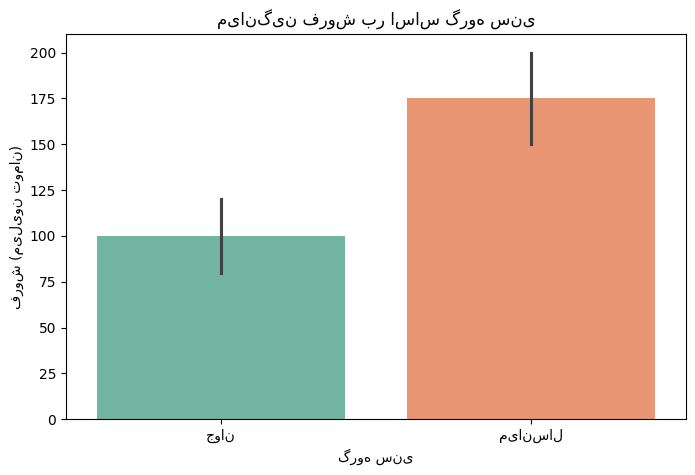

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# داده‌های نمونه
data = pd.DataFrame({
    'گروه_سنی': ['جوان', 'میانسال', 'جوان', 'میانسال', 'جوان'],
    'فروش': [100, 150, 120, 200, 80]
})

# رسم نمودار میله‌ای
plt.figure(figsize=(8, 5))
sns.barplot(x='گروه_سنی', y='فروش', data=data, palette='Set2')
plt.title('میانگین فروش بر اساس گروه سنی')
plt.xlabel('گروه سنی')
plt.ylabel('فروش (میلیون تومان)')
plt.show()

**خروجی**: نمودار میله‌ای که میانگین فروش گروه‌های سنی (جوان و میانسال) را مقایسه می‌کند.

<div dir="rtl" style="text-align: right;">

### ۴.۲. نمودار جعبه‌ای (Box Plot)
- **کاربرد**: نمایش توزیع داده‌ها (میانه، چارک‌ها، پرت‌ها) برای هر گروه.
- **مثال**: مقایسه توزیع فروش بین گروه‌های سنی.
<div/>

C:\Users\karvarz\AppData\Local\Temp\ipykernel_13292\1583051569.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='گروه_سنی', y='فروش', data=data, palette='Set2')


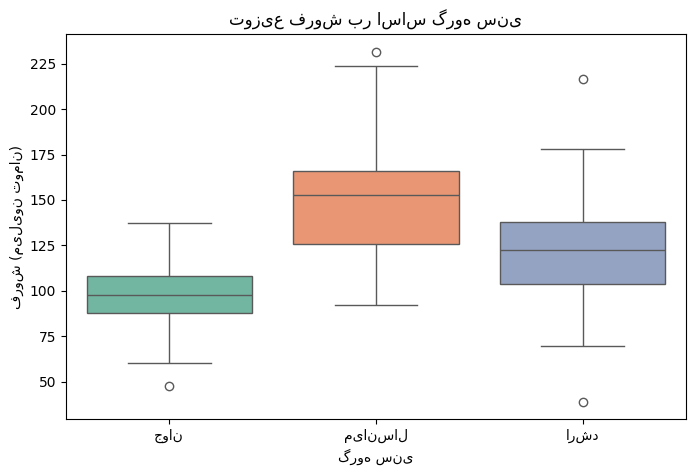

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np



# داده‌های نمونه
np.random.seed(42)
data = pd.DataFrame({
    'گروه_سنی': ['جوان']*100 + ['میانسال']*100 + ['ارشد']*100,
    'فروش': np.concatenate([
        np.random.normal(100, 20, 100),  # جوان
        np.random.normal(150, 30, 100),  # میانسال
        np.random.normal(120, 25, 100)   # ارشد
    ])
})

# رسم نمودار جعبه‌ای
plt.figure(figsize=(8, 5))
sns.boxplot(x='گروه_سنی', y='فروش', data=data, palette='Set2')
plt.title('توزیع فروش بر اساس گروه سنی')
plt.xlabel('گروه سنی')
plt.ylabel('فروش (میلیون تومان)')
plt.show()

**خروجی**: نمودار جعبه‌ای که توزیع فروش (میانه، چارک‌ها، پرت‌ها) را برای هر گروه سنی نشان می‌دهد.

<div dir="rtl" style="text-align: right;">

### ۴.۳. نمودار فراوانی (Count Plot)
- **کاربرد**: نمایش تعداد داده‌ها در هر دسته.
- **مثال**: تعداد افراد در هر گروه سنی.
<div/>

C:\Users\karvarz\AppData\Local\Temp\ipykernel_13292\1960328907.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='گروه_سنی', data=data, palette='Set2')
findfont: Font family 'Vazir' not found.
findfont: Font family 'Vazir' not found.
findfont: Font family 'Vazir' not found.
findfont: Font family 'Vazir' not found.
findfont: Font family 'Vazir' not found.
findfont: Font family 'Vazir' not found.
findfont: Font family 'Vazir' not found.
findfont: Font family 'Vazir' not found.
findfont: Font family 'Vazir' not found.
findfont: Font family 'Vazir' not found.
findfont: Font family 'Vazir' not found.
findfont: Font family 'Vazir' not found.
findfont: Font family 'Vazir' not found.
findfont: Font family 'Vazir' not found.
findfont: Font family 'Vazir' not found.
findfont: Font family 'Vazir' not found.
findfont: Font family 'Vazir' not 

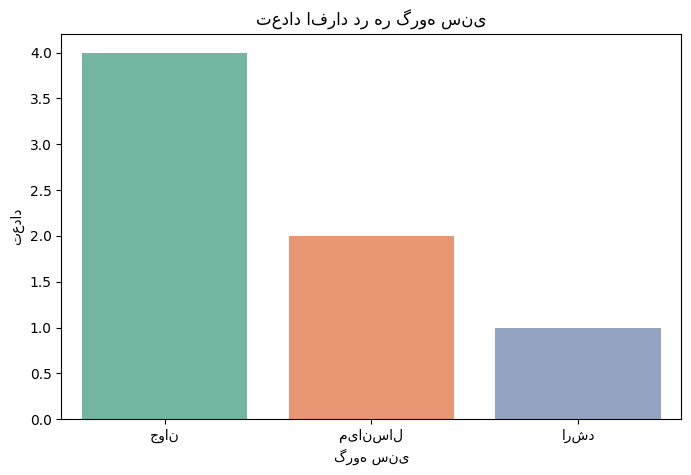

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# داده‌های نمونه
data = pd.DataFrame({
    'گروه_سنی': ['جوان', 'میانسال', 'جوان', 'میانسال', 'جوان', 'ارشد', 'جوان']
})

# رسم نمودار فراوانی
plt.figure(figsize=(8, 5))
sns.countplot(x='گروه_سنی', data=data, palette='Set2')
plt.title('تعداد افراد در هر گروه سنی')
plt.xlabel('گروه سنی')
plt.ylabel('تعداد')
plt.show()

<div dir="rtl" style="text-align: right;">

**خروجی**: نمودار میله‌ای که تعداد افراد در هر گروه سنی (جوان، میانسال، ارشد) را نشان می‌دهد.

**نکته تدریسی**: از دانشجویان بخواهید نمودارهای مختلف (میله‌ای، جعبه‌ای، فراوانی) را برای یک دیتاست واقعی رسم کنند و تفاوت‌های بصری و اطلاعاتی آن‌ها را توضیح دهند.

---
<div/>